<a href="https://colab.research.google.com/github/Qalb-e-Momin777/Practices/blob/main/PyTorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

what_were_covering = {1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together"
}

1. Data (preparing and loading)
I want to stress that "data" in machine learning can be almost anything you can imagine. A table of numbers (like a big Excel spreadsheet), images of any kind, videos (YouTube has lots of data!), audio files like songs or podcasts, protein structures, text and more.

Machine learning is a game of two parts:

Turn your data, whatever it is, into numbers (a representation).
Pick or build a model to learn the representation as best as possible.

In [111]:
import torch
from torch import nn
import matplotlib.pyplot as plt
# Linear Regression (y = mx + d)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*X + bias
X[:10] , y[:10] , len(X) , len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [112]:
train_split = int(0.8*len(X))
X_train , y_train = X[:train_split] , y[:train_split]
X_test , y_test = X[train_split:] , y[train_split:]
len(X_train) , len(y_train) , len(X_test) , len(y_test)

(40, 40, 10, 10)

In [113]:
#visualize the data
def plot_predictions(train_data = X_train,
                    train_label = y_train,
                    test_data = X_test,
                    test_label = y_test,
                    predictions = None):
  plt.figure(figsize = (10,7))
  plt.scatter(train_data , train_label , c="b" , s = 4 , label="Training data")
  plt.scatter(test_data , test_label , c="g" , s=4, label="testing data")
  if predictions is not None:
    plt.scatter(test_data , predictions , c = "r" , s=4)
  plt.legend(prop={"size":14})

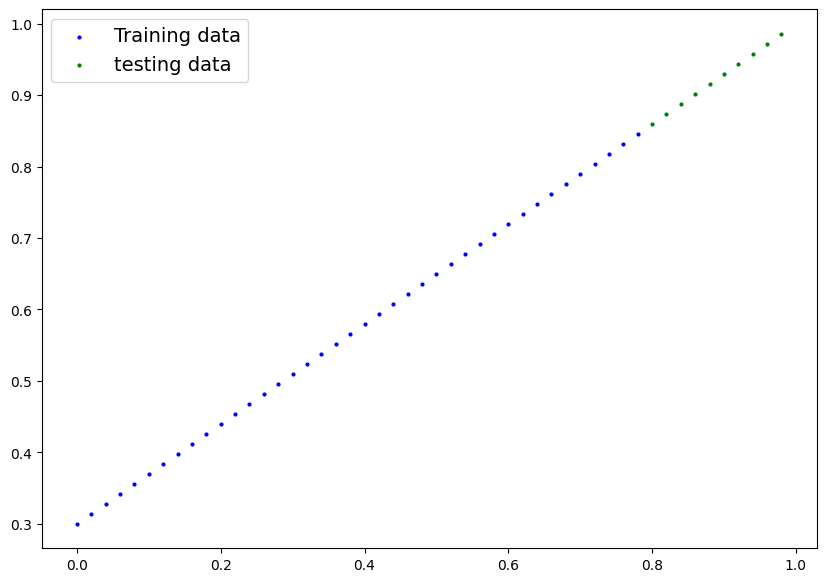

In [114]:
plot_predictions()

**Build A Model**
nn.Module is a base class for all neural networks if you want to create any model like CNN,Linear Regression etc

In [115]:
import torch
from torch import nn
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
  def forward(self , x):
    return self.weight*x + self.bias





List()
What it does:

Returns a list of all learnable parameters (weights & biases) in the model.

state_dict()
What it does:

Returns a dictionary of all model parameters + buffers

In [116]:
torch.manual_seed(42)
model = LinearRegressionModel()
list(model.parameters())
model.state_dict()


OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [117]:
weight , bias

(0.7, 0.3)

In [118]:
# make predictions with model
# Inference_mode turn off all the training_related trackinf to make predictions (inference) faster and memory efficient
with torch.inference_mode():
  y_pred = model(X_test)
y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

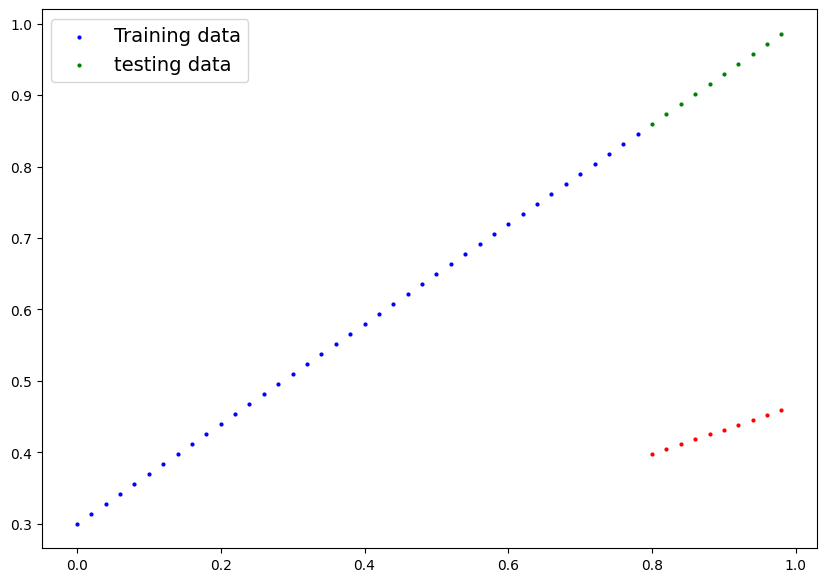

In [119]:
plot_predictions(predictions=y_pred)

In [120]:
model.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

**Loss Function**
1. Loss Functions (torch.nn)

👉 A loss function tells how wrong your model is
**Optimizer**
2. Optimizers (torch.optim)

👉 Optimizer updates model weights to reduce loss

In [121]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters() , lr=0.01)

 Building a Training Loop (and a Testing Loop)


In [122]:
torch.manual_seed(42)
# an epoch is a one loop through the data
epoch = 100
epoch_count = []
loss_values = []
test_loss_values = []
# Loop throgh the data
for epoch in range(epoch):
  # set the model to training mode
  model.train()
  # forward pass
  y_pred = model(X_train).unsqueeze(dim=1)
  # calculte the loss
  loss = loss_fn(y_pred , y_train.unsqueeze(dim=1))
  print(f"Loss : {loss}")
  # Optimizer zero grad
  optimizer.zero_grad()
  # perform backpropagation
  loss.backward()
  # optimizer step
  optimizer.step()
  # Testing
  model.eval()
  with torch.inference_mode():
    test_pred = model(X_test).unsqueeze(dim=1)
    test_loss = loss_fn(test_pred , y_test.unsqueeze(dim=1))
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss.detach().cpu().item())
    test_loss_values.append(test_loss.detach().cpu().item())
    print(f"Epoch : {epoch} | loss : {loss} | Test Loss : {test_loss}")
    print(model.state_dict())

Loss : 0.31288138031959534
Epoch : 0 | loss : 0.31288138031959534 | Test Loss : 0.48106518387794495
OrderedDict({'weight': tensor([0.3406]), 'bias': tensor([0.1388])})
Loss : 0.3013603389263153
Loss : 0.28983935713768005
Loss : 0.2783183455467224
Loss : 0.26679736375808716
Loss : 0.2552763521671295
Loss : 0.24375534057617188
Loss : 0.23223432898521423
Loss : 0.22071333229541779
Loss : 0.20919232070446014
Loss : 0.1976713240146637
Epoch : 10 | loss : 0.1976713240146637 | Test Loss : 0.3463551998138428
OrderedDict({'weight': tensor([0.3796]), 'bias': tensor([0.2388])})
Loss : 0.18615034222602844
Loss : 0.1746293306350708
Loss : 0.16310831904411316
Loss : 0.1515873372554779
Loss : 0.14006635546684265
Loss : 0.1285453587770462
Loss : 0.11702437698841095
Loss : 0.1060912236571312
Loss : 0.09681284427642822
Loss : 0.08908725529909134
Epoch : 20 | loss : 0.08908725529909134 | Test Loss : 0.21729660034179688
OrderedDict({'weight': tensor([0.4184]), 'bias': tensor([0.3333])})
Loss : 0.082275830

In [123]:
weight , bias

(0.7, 0.3)

In [124]:
with torch.inference_mode():
  y_pred_new = model(X_test)

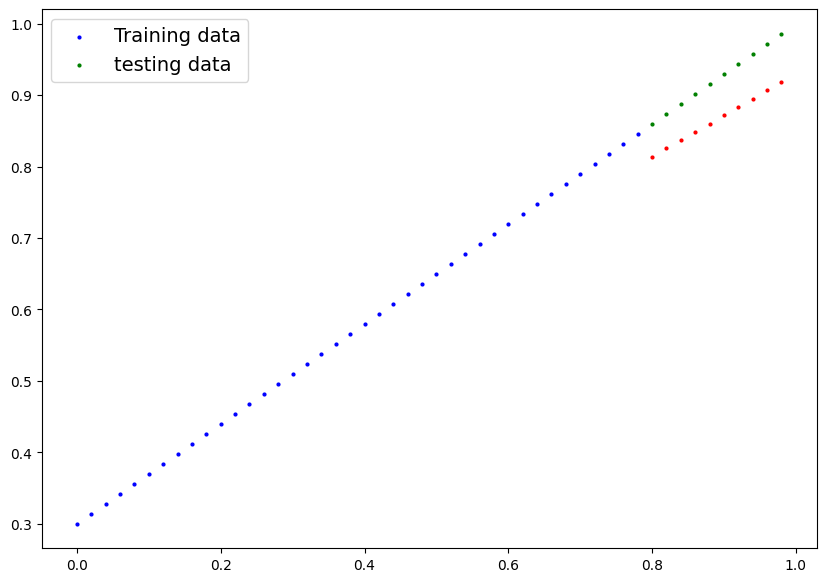

In [125]:
plot_predictions(predictions=y_pred_new)

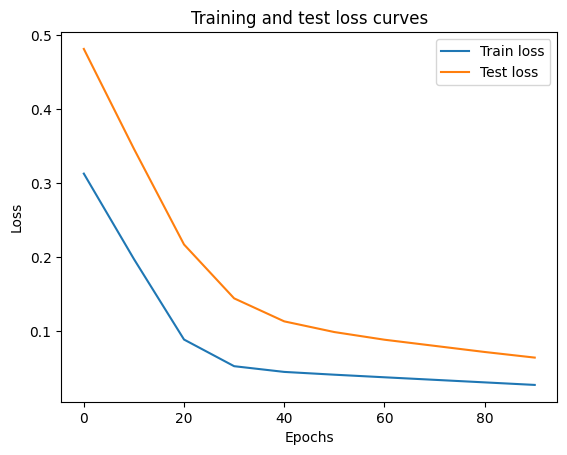

In [126]:
# Plot the loss curves
plt.plot(epoch_count, loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

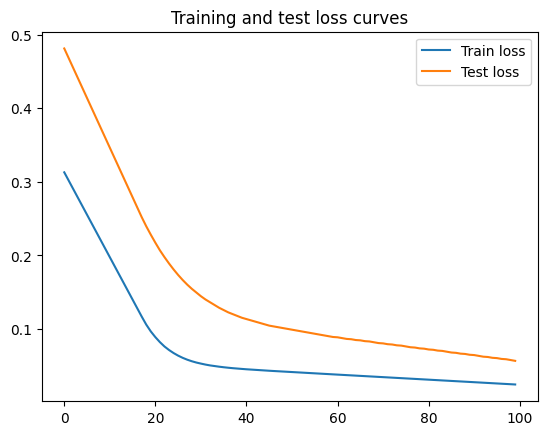

In [127]:
torch.manual_seed(42)
model = LinearRegressionModel() # Create a NEW model
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epoch = 100
epoch_count = []
loss_values = []
test_loss_values = []

# 2. Training Loop
for epoch in range(epoch):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 3. Test and Record
    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

        # Record data every epoch to see a smooth curve
        epoch_count.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())

# 4. Plot
plt.plot(epoch_count, loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.legend()
plt.show()

In [128]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [129]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 May  7 11:56 01_pytorch_workflow_model_0.pth


In [130]:
model.state_dict()

OrderedDict([('weight', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [131]:
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [132]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [133]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

Device : cpu


In [139]:
from torch import nn
# create another model
class LinearRegressionModel_1(nn.Module):
  def __init__(self):
    super().__init__()
    self.Linera_inner = nn.Linear(in_features=1,
                                  out_features=1)
  def forward(self , x: torch.Tensor)->torch.Tensor:
    return self.Linera_inner(x)

  torch.manual_seed(42)
model_1 = LinearRegressionModel_1()
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr =0.01)
# print(model_1.state_dict())
# check Model Device
# print(next(model_1.parameters()).device)
# model_1.to(device)
# next(model_1.parameters()).device

# Train the mode
torch.manual_seed(42)

epoch = 1000
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)
# Loop through the data
for epoch in range(epoch):
  # train the model
  model_1.train()
  # forward pass
  y_pred = model_1(X_train)
  # loss function
  loss = loss_fn(y_pred , y_train)
  # optimizer zero grad
  optimizer.zero_grad()
  # loss backward
  loss.backward()
  # optimizer Step
  optimizer.step()

# testing
  model_1.eval()
  with torch.inference_mode():
   test_pred = model_1(X_test)
  test_loss = loss_fn(test_pred , y_test)
  if epoch % 10 == 0:
   print(f"Epoch : {epoch} | Train Loss : {loss} | Test Loss: {test_loss}")

Epoch : 0 | Train Loss : 0.5551779866218567 | Test Loss: 0.5739762187004089
Epoch : 10 | Train Loss : 0.4399680495262146 | Test Loss: 0.4392663538455963
Epoch : 20 | Train Loss : 0.3247582018375397 | Test Loss: 0.30455657839775085
Epoch : 30 | Train Loss : 0.20954827964305878 | Test Loss: 0.16984674334526062
Epoch : 40 | Train Loss : 0.09433844685554504 | Test Loss: 0.03513689711689949
Epoch : 50 | Train Loss : 0.023886386305093765 | Test Loss: 0.04784906655550003
Epoch : 60 | Train Loss : 0.0199567973613739 | Test Loss: 0.04580312222242355
Epoch : 70 | Train Loss : 0.016517987474799156 | Test Loss: 0.0375305712223053
Epoch : 80 | Train Loss : 0.013089170679450035 | Test Loss: 0.029944902285933495
Epoch : 90 | Train Loss : 0.009653178043663502 | Test Loss: 0.02167237363755703
Epoch : 100 | Train Loss : 0.006215679459273815 | Test Loss: 0.014086711220443249
Epoch : 110 | Train Loss : 0.002787243574857712 | Test Loss: 0.005814164876937866
Epoch : 120 | Train Loss : 0.0012645035749301314 

In [141]:
model_1.eval()
with torch.inference_mode():
  y_pred = model_1(X_test)
y_pred


tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

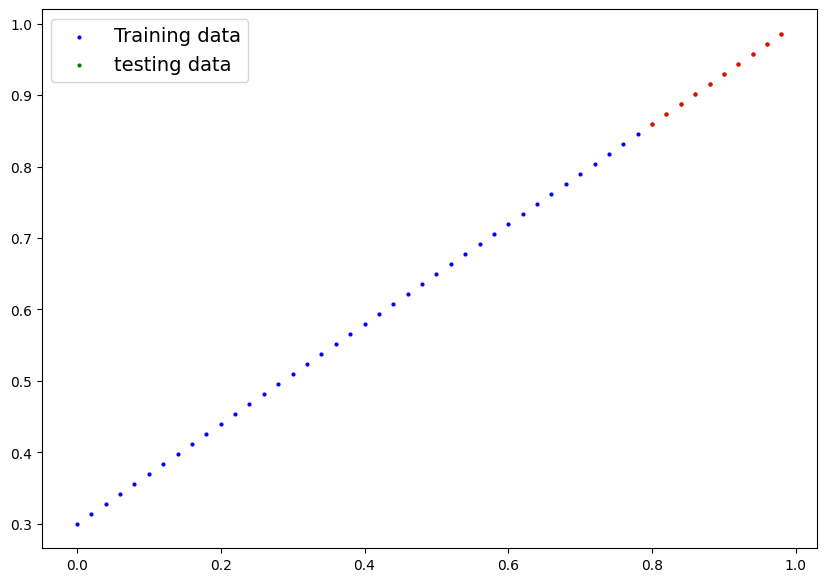

In [142]:
plot_predictions(predictions=y_pred.detach().cpu().numpy())